In [ ]:
# def calc_gradients(image):
#     Gx = np.array([[-1, 0, 1]], dtype=np.float32)
#     Gy = np.array([[-1], [0], [1]], dtype=np.float32)

#     gradients_x = np.zeros(images.shape, dtype=np.float32)
#     gradients_y = np.zeros(images.shape, dtype=np.float32)
#     gradients_magnitude = np.zeros(images.shape, dtype=np.float32)
#     gradients_orientation = np.zeros(images.shape, dtype=np.float32)

#     img = images[i].astype(np.float32)
#     gx = cv2.filter2D(img, -1, Gx)
#     gy = cv2.filter2D(img, -1, Gy)
#     gradients_x[i] = gx
#     gradients_y[i] = gy
#     gradients_magnitude[i] = np.sqrt(gx**2 + gy**2)
#     gradients_orientation[i] = (np.arctan2(gy, gx) * 180 / np.pi) % 180

#     return gradients_magnitude, gradients_orientation

In [ ]:
# chunk_size = 100
# num_chunks = (train_x.shape[0] + chunk_size - 1) // chunk_size

# train_x_grandients_magnitude = np.zeros((0, 128, 128), dtype=np.float32)
# train_x_gradients_orientation = np.zeros((0, 128, 128), dtype=np.float32)
# test_x_grandients_magnitude = np.zeros((0, 128, 128), dtype=np.float32)
# test_x_gradients_orientation = np.zeros((0, 128, 128), dtype=np.float32)

# for i in range(num_chunks):
#     print(f"Processing chunk {i + 1}/{num_chunks}")
#     start = i * chunk_size
#     end = min((i + 1) * chunk_size, train_x.shape[0])
#     gradients_magnitude, gradients_orientation = calc_gradients(train_x[start:end])
#     train_x_grandients_magnitude = np.concatenate((train_x_grandients_magnitude, gradients_magnitude), axis=0)
#     train_x_gradients_orientation = np.concatenate((train_x_gradients_orientation, gradients_orientation), axis=0)


# for i in range(num_chunks):
#     print(f"Processing chunk {i + 1}/{num_chunks}")
#     start = i * chunk_size
#     end = min((i + 1) * chunk_size, test_x.shape[0])
#     gradients_magnitude, gradients_orientation = calc_gradients(test_x[start:end])
#     test_x_grandients_magnitude = np.concatenate((test_x_grandients_magnitude, gradients_magnitude), axis=0)
#     test_x_gradients_orientation = np.concatenate((test_x_gradients_orientation, gradients_orientation), axis=0)    



In [ ]:
# print("train_x_grandients_magnitude shape:", train_x_grandients_magnitude.shape)
# print("train_x_gradients_orientation shape:", train_x_gradients_orientation.shape)
# print("test_x_grandients_magnitude shape:", test_x_grandients_magnitude.shape)
# print("test_x_gradients_orientation shape:", test_x_gradients_orientation.shape)

In [ ]:
# with open("train_x_gradients_orientation.npy", "wb") as f:
#     np.save(f, train_x_gradients_orientation)
# with open("test_x_gradients_orientation.npy", "wb") as f:
#     np.save(f, test_x_gradients_orientation)

# with open("train_x_grandients_magnitude.npy", "wb") as f:
#     np.save(f, train_x_grandients_magnitude)
# with open("test_x_grandients_magnitude.npy", "wb") as f:
#     np.save(f, test_x_grandients_magnitude)

In [ ]:
# train_x_grandients_magnitude = np.load("train_x_grandients_magnitude.npy")
# train_x_gradients_orientation = np.load("train_x_gradients_orientation.npy")
# test_x_grandients_magnitude = np.load("test_x_grandients_magnitude.npy")
# test_x_gradients_orientation = np.load("test_x_gradients_orientation.npy")

In [ ]:
# n = train_x_grandients_magnitude.shape[0]
# train_hog_features = HoG(n, train_x_gradients_orientation, train_x_grandients_magnitude, cell_size, num_bins)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
def calc_gradients(image):
    Gx = np.array([[-1, 0, 1]], dtype=np.float32)
    Gy = np.array([[-1], [0], [1]], dtype=np.float32)

    image = image.astype(np.float32)

    gx = cv2.filter2D(image, -1, Gx)
    gy = cv2.filter2D(image, -1, Gy)
    
    gradients_magnitude = np.sqrt(gx**2 + gy**2)
    gradients_orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    return gradients_magnitude, gradients_orientation

In [3]:
def HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2):
    bin_size = 180 / num_bins

    h, w = orientations.shape
    cells_y = h // cell_size
    cells_x = w // cell_size

    histograms = np.zeros((cells_y, cells_x, num_bins), dtype=np.float32)
    
    for cy in range(cells_y):
        for cx in range(cells_x):
            y0 = cy * cell_size
            x0 = cx * cell_size

            for y in range(cell_size):
                for x in range(cell_size):
                    angle = orientations[y0 + y, x0 + x]
                    mag = magnitudes[y0 + y, x0 + x]

                    bin_idx = int(angle / bin_size) % num_bins
                    histograms[cy, cx, bin_idx] += mag
                    
    features = []

    for y in range(cells_y - 1):
        for x in range(cells_x - 1):
            block = histograms[y:y+block_size, x:x+block_size].flatten()

            norm = np.linalg.norm(block)
            block = block / (norm + 1e-6)

            features.extend(block)

    return np.array(features, dtype=np.float32)

In [4]:
IMG_SIZE = 128
images_folder = './data/digital'
folders = os.listdir(images_folder)
x_features = []
y_label = []
count = 0
for folder in folders:
    folder_path = os.path.join(images_folder, folder)
    label = folder.split('_')[0]
    print(f"Processing folder: {label}")
    for image_name in os.listdir(folder_path):
        count += 1
        print(f"Processing image: {count}")
        image_path = os.path.join(folder_path, image_name)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image.astype(np.float32) / 255.0
        magnitudes, orientations = calc_gradients(image)
        features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2)
        # features = hog(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm='L2-Hys')
        x_features.append(features)
        y_label.append(label)


Processing folder: 0
Processing image: 1
Processing image: 2
Processing image: 3
Processing image: 4
Processing image: 5
Processing image: 6
Processing image: 7
Processing image: 8
Processing image: 9
Processing image: 10
Processing image: 11
Processing image: 12
Processing image: 13
Processing image: 14
Processing image: 15
Processing image: 16
Processing image: 17
Processing image: 18
Processing image: 19
Processing image: 20
Processing image: 21
Processing image: 22
Processing image: 23
Processing image: 24
Processing image: 25
Processing image: 26
Processing image: 27
Processing image: 28
Processing image: 29
Processing image: 30
Processing image: 31
Processing image: 32
Processing image: 33
Processing image: 34
Processing image: 35
Processing image: 36
Processing image: 37
Processing image: 38
Processing image: 39
Processing image: 40
Processing image: 41
Processing image: 42
Processing image: 43
Processing image: 44
Processing image: 45
Processing image: 46
Processing image: 47
P

In [5]:
x = np.array(x_features)
y = np.array(y_label)
print("Feature shape:", x.shape)
print("Label shape:", y.shape)
print("Unique labels:", np.unique(y))

Feature shape: (62992, 1764)
Label shape: (62992,)
Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'd' 'e' 'f' 'g' 'h' 'n' 'q' 'r' 't']


In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
train_x, test_x, train_y, test_y = train_test_split(x, y_encoded, test_size=0.1, random_state=42)

In [7]:
model = LinearSVC(random_state=42, max_iter=10000, C = 2.0, class_weight='balanced')
model.fit(train_x, train_y)

LinearSVC(C=2.0, class_weight='balanced', max_iter=10000, random_state=42)

In [9]:
joblib.dump(model, 'hog_manual_svm_model.joblib')

['hog_manual_svm_model.joblib']

In [10]:
predictions = model.predict(test_x)
F1 = f1_score(test_y, predictions, average='weighted')
print("F1 Score:", F1)

F1 Score: 0.9521827622429071


In [12]:
def predict(image):
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image.astype(np.float32) / 255.0
    magnitudes, orientations = calc_gradients(image)
    # test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    magnitudes, orientations = calc_gradients(image)
    test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    predicted_label = model.predict(test_features)
    print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])

Predicted label for test image: A


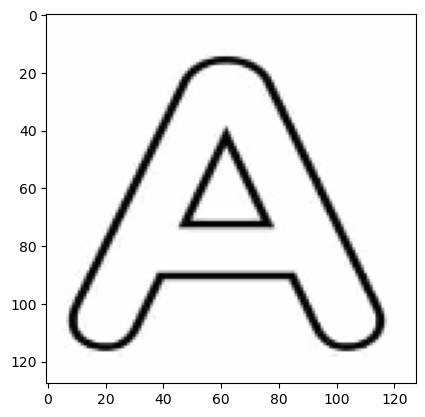

In [21]:
image = cv2.imread('test.jpeg', cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
plt.imshow(image, cmap='gray')
predict(image)